In [7]:
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.wcs import WCS
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
from astroquery.mast import Observations, Mast
from pprint import pprint
import os
import re
import glob

mast = Mast()

target_name = "NGC 4449"

# Check if FITS files already exist on disk for this target
fits_dir = f"./fits_images/{target_name}"
_skip_query = False
if os.path.isdir(fits_dir):
    existing = glob.glob(os.path.join(fits_dir, "*_i2d.fits"))
    if existing:
        print(f"Found {len(existing)} FITS file(s) on disk in {fits_dir} — skipping MAST query.")
        for p in sorted(existing):
            print(f"  {os.path.basename(p)}")
        _skip_query = True

if not _skip_query:
    obs = Observations.query_object(target_name, radius="0.1 deg")

    miri_obs = obs[
        (obs['instrument_name'] == 'MIRI/IMAGE') &
        (obs['dataproduct_type'] == 'image') &
        (obs['obs_collection'] == 'JWST') &
        (obs['dataRights'] == 'PUBLIC')
    ]
    print(f"MAST query returned {len(miri_obs)} MIRI/IMAGE observations.")


MAST query returned 43 MIRI/IMAGE observations.


In [8]:
miri_obs

intentType,obs_collection,provenance_name,instrument_name,project,filters,wave_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,wavelength_region,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,wave_min,wave_max,distance
str11,str5,str31,str17,str10,str26,str16,str33,str128,str58,float64,float64,str10,str21,int64,float64,float64,float64,str16,float64,float64,str111,float64,str5,str10,int64,str1357,str181,str182,str6,bool,float64,str9,float64,float64,float64
science,JWST,CALJWST,MIRI/IMAGE,JWST,F560W,INFRARED,NGC4449-MIRI,Galaxy; Dwarf irregular galaxies; Magellanic Irregular Galaxies,jw01783-c1016_t012_miri_f560w,187.04604208333333,44.095394444444445,image,"Adamo, Angela",3,60080.94893658889,60450.70640056713,599.4120000000001,INFRARED,5000.0,6200.0,JWST probes Feedback in Emerging extrAgalactic Star clusTers: JWST-FEAST,60815.81951374,1783,GO,--,POLYGON 187.058396834 44.128938893 187.092057202 44.103160902 187.019578573 44.05432662 186.985914429 44.080083329,mast:JWST/product/jw01783-c1016_t012_miri_f560w_i2d.jpg,mast:JWST/product/jw01783-c1016_t012_miri_f560w_i2d.fits,PUBLIC,False,nan,218220699,5000.0,6200.0,0.0
science,JWST,CALJWST,MIRI/IMAGE,JWST,F770W,INFRARED,NGC4449-MIRI,Galaxy; Dwarf irregular galaxies; Magellanic Irregular Galaxies,jw01783-c1016_t012_miri_f770w,187.04604208333333,44.095394444444445,image,"Adamo, Angela",3,60080.956323895836,60450.712792418984,333.0,INFRARED,6600.0,8800.0,JWST probes Feedback in Emerging extrAgalactic Star clusTers: JWST-FEAST,60815.81951374,1783,GO,--,POLYGON 187.058400864 44.128939728 187.09206104 44.103162498 187.019583113 44.054327527 186.985919162 44.080083475,mast:JWST/product/jw01783-c1016_t012_miri_f770w_i2d.jpg,mast:JWST/product/jw01783-c1016_t012_miri_f770w_i2d.fits,PUBLIC,False,nan,218207079,6600.0,8800.0,0.0
science,JWST,CALJWST,MIRI/IMAGE,JWST,F560W,INFRARED,NGC4449-MIRI,Galaxy; Dwarf irregular galaxies; Magellanic Irregular Galaxies,jw01783-o010_t012_miri_f560w,187.04604208333333,44.095394444444445,image,"Adamo, Angela",3,60080.94893658565,60080.97231914352,399.60800000000006,INFRARED,5000.0,6200.0,JWST probes Feedback in Emerging extrAgalactic Star clusTers: JWST-FEAST,60447.6432754,1783,GO,--,POLYGON 187.039584703 44.116289054 187.073097456 44.090624513 187.0193961 44.054438016 186.985880561 44.080086858,mast:JWST/product/jw01783-o010_t012_miri_f560w_i2d.jpg,mast:JWST/product/jw01783-o010_t012_miri_f560w_i2d.fits,PUBLIC,False,nan,137398176,5000.0,6200.0,0.0
science,JWST,CALJWST,MIRI/IMAGE,JWST,F770W,INFRARED,NGC4449-MIRI,Galaxy; Dwarf irregular galaxies; Magellanic Irregular Galaxies,jw01783-o010_t012_miri_f770w,187.04604208333333,44.095394444444445,image,"Adamo, Angela",3,60080.956323900464,60080.978646539355,222.0,INFRARED,6600.0,8800.0,JWST probes Feedback in Emerging extrAgalactic Star clusTers: JWST-FEAST,60447.6432754,1783,GO,--,POLYGON 187.039588838 44.116289658 187.073102016 44.090625403 187.019401258 44.054438448 186.985885295 44.080087004,mast:JWST/product/jw01783-o010_t012_miri_f770w_i2d.jpg,mast:JWST/product/jw01783-o010_t012_miri_f770w_i2d.fits,PUBLIC,False,nan,137398173,6600.0,8800.0,0.0
science,JWST,CALJWST,MIRI/IMAGE,JWST,F560W,INFRARED,NGC4449-MIRI,Galaxy; Dwarf irregular galaxies; Magellanic Irregular Galaxies,jw01783-o916_t012_miri_f560w,187.04604208333333,44.095394444444445,image,"Adamo, Angela",3,60450.7011328125,60450.70640056713,199.804,INFRARED,5000.0,6200.0,JWST probes Feedback in Emerging extrAgalactic Star clusTers: JWST-FEAST,60815.81935175,1783,GO,--,POLYGON 187.058606565 44.128763932 187.092034588 44.103164338 187.057112043 44.079649667 187.0236822 44.105239077,mast:JWST/product/jw01783-o916_t012_miri_f560w_i2d.jpg,mast:JWST/product/jw01783-o916_t012_miri_f560w_i2d.fits,PUBLIC,False,nan,214776510,5000.0,6200.0,0.0
science,JWST,CALJWST,MIRI/IMAGE,JWST,F770W,INFRARED,NGC4449-MIRI,Gala

In [9]:
target_filters = ['F770W', 'F1500W', 'F2550W']

if _skip_query:
    # Already have files on disk — detect which filters are available
    for f in target_filters:
        matches = [p for p in existing if f"_f{f[1:].lower()}" in os.path.basename(p).lower()]
        status = "found on disk" if matches else "MISSING"
        print(f"  {f}: {status}")
    print("\nSkipped MAST filter step — using local files.")
else:
    filtered_by_filter = {}
    for f in target_filters:
        filtered_by_filter[f] = miri_obs[miri_obs['filters'] == f]

    for f, data in filtered_by_filter.items():
        print(f"\n=== Filter: {f} ===")
        print(f"Count: {len(data)}")
        for row in data:
            print(f"  obs_id: {row['obs_id']} | filters: {row['filters']} | t_exptime: {row['t_exptime']}")

    from astropy.table import vstack
    all_filtered = vstack([filtered_by_filter[f] for f in target_filters if len(filtered_by_filter[f]) > 0])
    print(f"\nTotal across all 3 filters: {len(all_filtered)}")



=== Filter: F770W ===
Count: 5
  obs_id: jw01783-c1016_t012_miri_f770w | filters: F770W | t_exptime: 333.0
  obs_id: jw01783-o010_t012_miri_f770w | filters: F770W | t_exptime: 222.0
  obs_id: jw01783-o916_t012_miri_f770w | filters: F770W | t_exptime: 111.0
  obs_id: jw01783-o915_t013_miri_f770w | filters: F770W | t_exptime: 111.0
  obs_id: jw01783-o012_t013_miri_f770w | filters: F770W | t_exptime: 111.0

=== Filter: F1500W ===
Count: 0

=== Filter: F2550W ===
Count: 0

Total across all 3 filters: 5


In [10]:
# === OPTIONAL: Filter by proposal_id so all bands come from the same program ===
# Delete this entire cell if you don't want proposal filtering.

if not _skip_query and len(all_filtered) > 0:
    # Show which proposals have which filters
    proposals = sorted(set(all_filtered['proposal_id']))
    print("Proposals with your requested filters:\n")
    best_pid, best_count = None, 0
    for pid in proposals:
        pid_rows = all_filtered[all_filtered['proposal_id'] == pid]
        pid_filters = sorted(set(pid_rows['filters']))
        match_count = len([f for f in target_filters if f in pid_filters])
        marker = ""
        if match_count > best_count:
            best_count = match_count
            best_pid = pid
        print(f"  PID {pid}: filters={pid_filters} ({match_count}/{len(target_filters)} match)")

    # Re-rank only proposals that have downloadable data (robust masked-value check)
    best_pid, best_count = None, 0
    for pid in proposals:
        pid_rows = all_filtered[all_filtered['proposal_id'] == pid]
        has_url = []
        for r in pid_rows:
            url = str(r['dataURL']).strip() if r['dataURL'] else ''
            if url and url != '--' and url != 'None':
                has_url.append(r)
        if not has_url:
            continue
        pid_filters = sorted(set(str(r['filters']) for r in has_url))
        match_count = len([f for f in target_filters if f in pid_filters])
        if match_count > best_count:
            best_count = match_count
            best_pid = pid

    print(f"\nBest downloadable match: PID {best_pid} ({best_count}/{len(target_filters)} filters)")

    if best_count >= 2:
        print(f"Filtering all_filtered to PID {best_pid} only.")
        all_filtered = all_filtered[all_filtered['proposal_id'] == best_pid]
        print(f"Rows after proposal filter: {len(all_filtered)}")
    else:
        print(f"No single proposal has 2+ downloadable matching filters — skipping proposal filter.")
        print(f"Using first available observation per filter (coverage may differ).")

Proposals with your requested filters:

  PID 1783: filters=[np.str_('F770W')] (1/3 match)

Best downloadable match: PID 1783 (1/3 filters)
No single proposal has 2+ downloadable matching filters — skipping proposal filter.
Using first available observation per filter (coverage may differ).


In [11]:
if _skip_query:
    print(f"All files already on disk in {fits_dir} — nothing to download.")
else:
    for f in target_filters:
        filter_obs = all_filtered[all_filtered['filters'] == f]

        if len(filter_obs) == 0:
            print(f"No observations found for filter {f}, skipping...")
            continue

        save_dir = f"./fits_images/{target_name}"
        os.makedirs(save_dir, exist_ok=True)

        # Check if already on disk
        already = glob.glob(os.path.join(save_dir, f"*_{f.lower()}_i2d.fits"))
        if already:
            print(f"  {f}: already on disk")
            continue

        # Try each observation until one downloads successfully
        got_it = False
        for row in filter_obs:
            dataURL = str(row['dataURL']).strip() if row['dataURL'] else ''
            if not dataURL or dataURL == '--':
                continue
            filename = dataURL.split("/")[-1]
            local_path = f"{save_dir}/{filename}"
            print(f"Downloading {f}: {filename}")
            Observations.download_file(dataURL, local_path=local_path)
            if os.path.exists(local_path) and os.path.getsize(local_path) > 1000:
                print(f"  Saved to {local_path}")
                got_it = True
                break
            else:
                print(f"  Download failed, trying next observation...")
                if os.path.exists(local_path):
                    os.remove(local_path)

        if not got_it:
            print(f"  WARNING: Could not download {f}")

# Save config so False_color.ipynb knows which target/filters to use
import json
config = {"target_name": target_name, "target_filters": target_filters}
with open("target_config.json", "w") as cfg:
    json.dump(config, cfg)
print(f"\nSaved target_config.json: {config}")

  Saved to ./fits_images/NGC 4449/jw01783-c1016_t012_miri_f770w_i2d.fits
No observations found for filter F1500W, skipping...
No observations found for filter F2550W, skipping...

Saved target_config.json: {'target_name': 'NGC 4449', 'target_filters': ['F770W', 'F1500W', 'F2550W']}


No FITS files found for NGC 4449 with filters ['F770W', 'F1500W', 'F2550W']


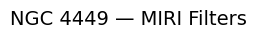

In [12]:
# Auto-discover local FITS files for plotting
import re as _re
local_fits = {}
for fpath in sorted(glob.glob(os.path.join(f"./fits_images/{target_name}", "*_i2d.fits"))):
    m = _re.search(r"_f(\d+w)", os.path.basename(fpath).lower())
    if m:
        filt = f"F{m.group(1).upper()}"
        if filt in target_filters:
            local_fits[filt] = fpath

found_filters = [f for f in target_filters if f in local_fits]
n_panels = max(len(found_filters), 1)

fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 6), squeeze=False)
axes = axes[0]

for i, f in enumerate(found_filters):
    local_path = local_fits[f]
    hdul = fits.open(local_path)

    try:
        cube = hdul['SCI'].data
    except KeyError:
        cube = hdul[1].data

    cube = np.squeeze(cube)

    if cube.ndim == 3:
        image = np.nansum(cube, axis=0)
    elif cube.ndim == 2:
        image = cube
    else:
        print(f"Cannot handle shape {cube.shape} for filter {f}, skipping...")
        hdul.close()
        continue

    image = np.where(image <= 0, np.nan, image)
    vmin = np.nanpercentile(image, 5)
    vmax = np.nanpercentile(image, 99)
    vmin = max(vmin, 1e-10)
    if vmin >= vmax:
        vmax = vmin * 10

    ax = axes[i]
    im = ax.imshow(
        image, origin='lower', cmap='inferno',
        norm=plt.matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax)
    )
    ax.set_title(f"{target_name} — {f}", fontsize=12)
    ax.set_xlabel("X (pixels)")
    ax.set_ylabel("Y (pixels)")
    plt.colorbar(im, ax=ax, label="Flux")
    hdul.close()

# Hide unused axes
for j in range(len(found_filters), len(axes)):
    axes[j].set_visible(False)

if not found_filters:
    print(f"No FITS files found for {target_name} with filters {target_filters}")

plt.suptitle(f"{target_name} — MIRI Filters", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()